El objetivo de este análisis es explorar el conjunto de datos de viajes de Citi Bike para identificar patrones de uso, entender el comportamiento de los diferentes tipos de usuario y descubrir las principales zonas de demanda en la ciudad.

## 3.1 Preparación del entorno

In [1]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual de los gráficos
sns.set_style('whitegrid')

# Definir los tipos para evitar advertencias
tipos_de_datos = {'ride_id': str}

# Cargar el dataset final y limpio desde el archivo CSV
df = pd.read_csv('../data/processed/trips_final_for_analysis.csv', dtype=tipos_de_datos)

# Corregir los tipos de fecha 
df['started_at'] = pd.to_datetime(df['started_at'])
df['ended_at'] = pd.to_datetime(df['ended_at'])

# Corregir los tipos de categoría que se pierden al guardar en CSV
for col in ['member_casual', 'day_of_week', 'month', 'rideable_type']:
    df[col] = df[col].astype('category')

print("Datos cargados con éxito")
df.info()

Datos cargados con éxito
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3131873 entries, 0 to 3131872
Data columns (total 15 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   ride_id                object        
 1   rideable_type          category      
 2   started_at             datetime64[ns]
 3   ended_at               datetime64[ns]
 4   member_casual          category      
 5   trip_duration_minutes  float64       
 6   start_hour             int64         
 7   day_of_week            category      
 8   month                  category      
 9   station_name_start     object        
 10  latitude_start         float64       
 11  longitude_start        float64       
 12  station_name_end       object        
 13  latitude_end           float64       
 14  longitude_end          float64       
dtypes: category(4), datetime64[ns](2), float64(5), int64(1), object(3)
memory usage: 274.8+ MB


## 3.2 Análisis descriptivo general

In [ ]:
# Obtenemos un resumen completo de los datos
df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
ride_id,3131873,3131873,0AE5FB7DFCB8E5BE,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rideable_type,3131873,2,electric_bike,2203317,NaN,NaN,NaN,NaN,NaN,NaN,NaN
started_at,3131873,NaN,NaN,NaN,2025-03-17 05:04:34.426012160,2025-02-28 14:53:42.803000,2025-03-10 08:54:39.008999936,2025-03-17 09:48:57.030000128,2025-03-25 08:09:36.471000064,2025-03-31 23:56:56.495000,NaN
ended_at,3131873,NaN,NaN,NaN,2025-03-17 05:15:50.782547200,2025-03-01 00:00:01.426000,2025-03-10 09:04:41.156000,2025-03-17 09:59:08.441999872,2025-03-25 08:19:50.321999872,2025-03-31 23:59:45.737000,NaN
member_casual,3131873,2,member,2691024,NaN,NaN,NaN,NaN,NaN,NaN,NaN
trip_duration_minutes,3131873.0,NaN,NaN,NaN,11.272609,1.0003,4.785167,8.064567,13.7525,1439.937983,16.542502
start_hour,3131873.0,NaN,NaN,NaN,13.919658,0.0,10.0,15.0,18.0,23.0,4.888736
day_of_week,3131873,7,Saturday,521391,NaN,NaN,NaN,NaN,NaN,NaN,NaN
month,3131873,2,March,3131495,NaN,NaN,NaN,NaN,NaN,NaN,NaN
station_name_start,3131873,2135,W 21 St & 6 Ave,12284,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Conclusión**

El dataset contiene 3.1M de viajes. La duración promedio de un viaje es de 11.2 minutos, aunque la mediana es de solo 8 minutos, lo que indica la presencia de viajes largos.

## 3.3 Análisis del comportamiento de usuario

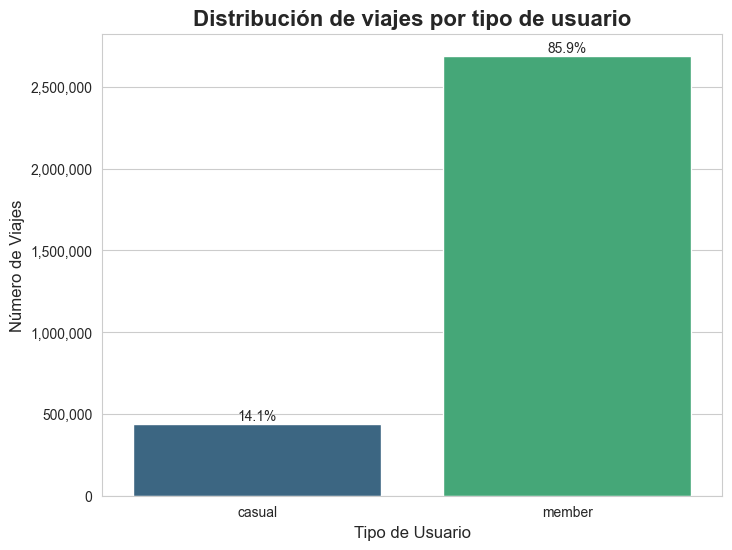

In [4]:
# Creamos el gráfico y lo guardamos en una variable 'ax' para poder manipularlo
plt.figure(figsize=(8, 6))
ax = sns.countplot(data=df,x='member_casual', palette='viridis', hue='member_casual', legend=False)

total = len(df) # El número total de viajes

# Iteramos sobre cada una de las barras del gráfico
for p in ax.patches:
    # Calculamos el porcentaje
    percentage = f'{100 * p.get_height() / total:.1f}%'
    # Definimos las coordenadas x e y para el texto
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    # Añadimos el texto al gráfico
    ax.annotate(percentage, (x, y), ha='center', va='bottom')

plt.title('Distribución de viajes por tipo de usuario', fontsize=16, fontweight='bold')
plt.xlabel('Tipo de Usuario', fontsize=12)
plt.ylabel('Número de Viajes', fontsize=12)
plt.gca().get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.show()

**Interpretación del Gráfico**

Existe un dominio claro de los usuarios miembros, constituyendo la gran mayoría de los viajes.

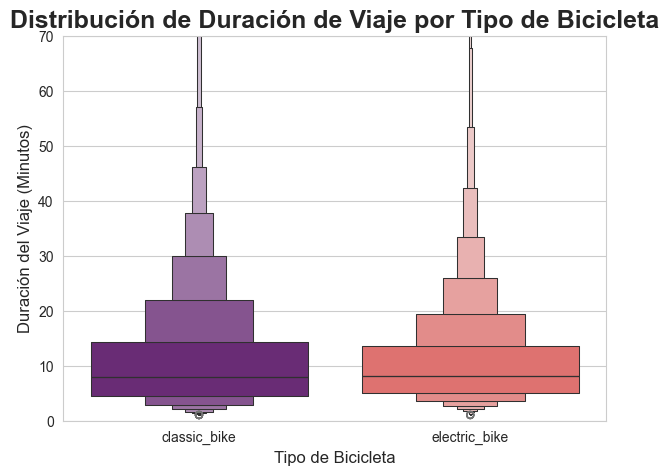

In [ ]:
# Boxenplot para comparar la duración por tipo de bicicleta
plt.figure(figsize=(7, 5))
sns.boxenplot(x='rideable_type', y='trip_duration_minutes', data=df, palette='magma',hue='rideable_type', legend=False)

plt.title('Distribución de duración de viaje por tipo de bicicleta', fontsize=18, fontweight='bold')
plt.xlabel('Tipo de Bicicleta', fontsize=12)
plt.ylabel('Duración del Viaje (Minutos)', fontsize=12)
plt.ylim(0, 70) # Limitamos el eje para una mejor visualización de la distribución
plt.show()

In [18]:
df.groupby('rideable_type', observed=True)['trip_duration_minutes'].median()

rideable_type
classic_bike     7.838300
electric_bike    8.150133
Name: trip_duration_minutes, dtype: float64

**Interpretación del Gráfico**

Aunque la diferencia visual es sutil, la mediana de duración de los viajes en bicicleta eléctrica (8.15 minutos) es mayor que la de las bicicletas clásicas (7.84 minutos). 

Esa pequeña pero consistente diferencia, multiplicada por millones de viajes, confirma el patrón de comportamiento: la gente usa las bicicletas eléctricas para hacer trayectos un poco más largos.

## 3.4 Análisis temporal
**Patrones horarios: Miembros vs. Casuales**

¿Cuáles son las horas más concurridas? ¿Quiénes son los que causan esos picos de demanda y por qué?

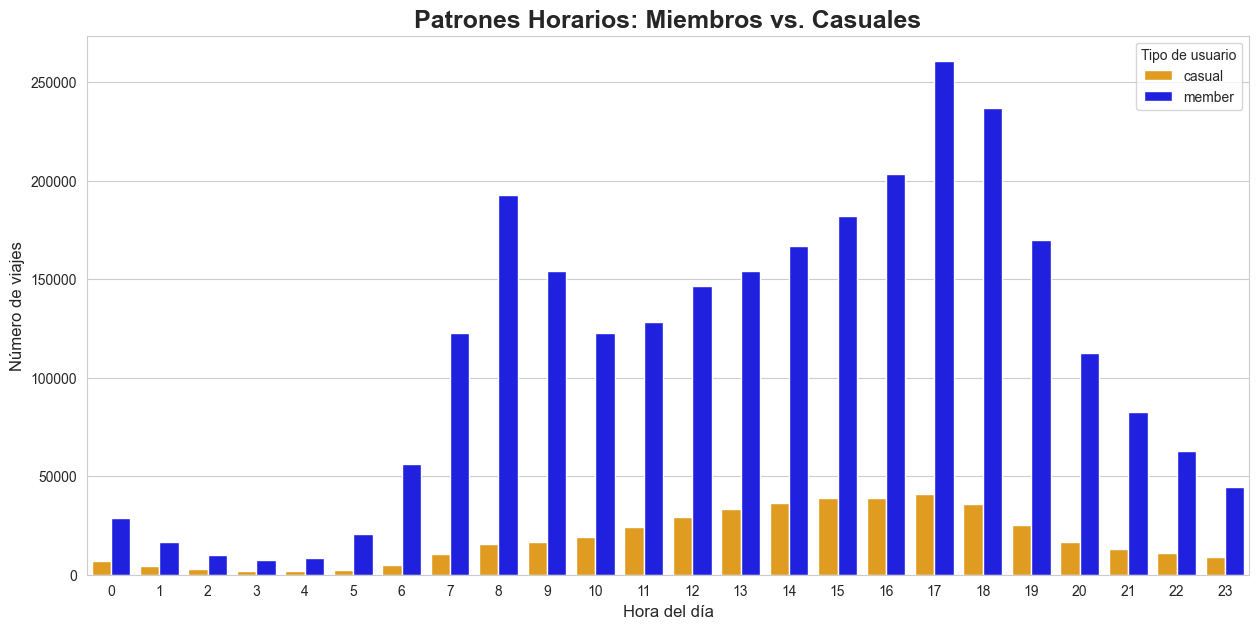

In [ ]:
# Gráfico de barras agrupado para analizar patrones horarios por tipo de usuario
plt.figure(figsize=(15, 7))
sns.countplot(data=df, x='start_hour', hue='member_casual', palette={'member': 'blue', 'casual': 'orange'})

plt.title('Patrones horarios: miembros vs. casuales', fontsize=18, fontweight='bold')
plt.xlabel('Hora del día', fontsize=12)
plt.ylabel('Número de viajes', fontsize=12)
plt.legend(title='Tipo de usuario')
plt.show()

**Interpretación del Gráfico**

El uso del servicio muestra dos patrones horarios muy claros. El principal es un patrón de "commuting" con picos de demanda entre las 7-9 a.m. y las 5-7 p.m. (horas inicio y fin de los trabajos), lo que confirma que las bicicletas son un componente clave del transporte diario para la vida laboral.

Este comportamiento es impulsado principalmente por los usuarios miembros, cuyo uso se concentra en esas franjas horarias. Por el contrario, los usuarios casuales muestran un patrón de ocio, menos "reglado" con una actividad más constante durante el mediodía y la tarde.

---

Análisis de Duración: ¿Se comportan igual los miembros y los casuales?

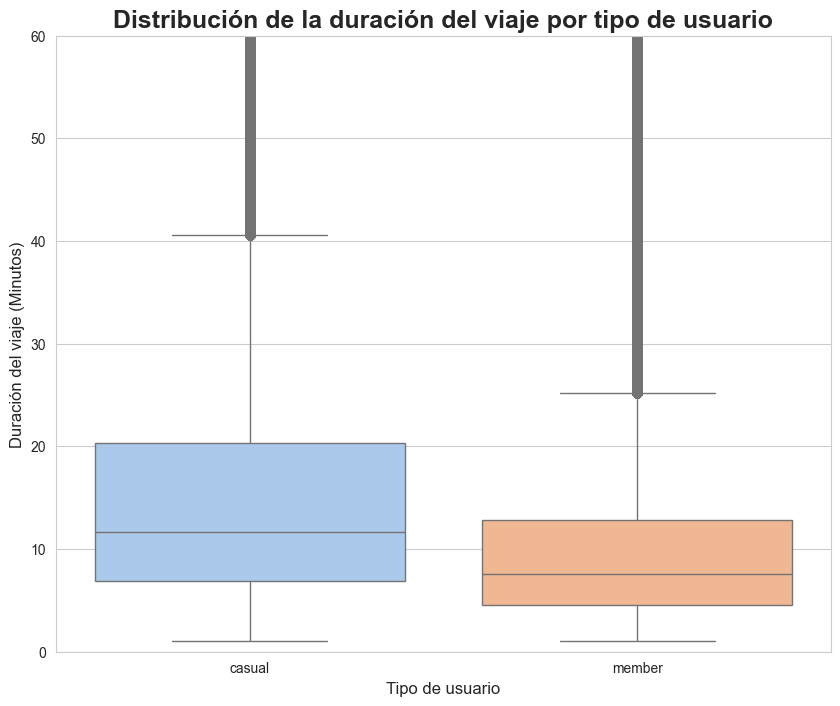

In [30]:
# Boxplot para analizar la duración por tipo de usuario
plt.figure(figsize=(10, 8))
sns.boxplot(x='member_casual', y='trip_duration_minutes', data=df, palette='pastel', hue='member_casual',legend=False)

plt.title('Distribución de la duración del viaje por tipo de usuario', fontsize=18, fontweight='bold')
plt.xlabel('Tipo de usuario', fontsize=12)
plt.ylabel('Duración del viaje (Minutos)', fontsize=12)
plt.ylim(0, 60) # Limitamos el eje Y a 60 minutos para ver mejor la distribución principal
plt.show()

**Interpretación del Gráfico**

Los usuarios casuales tienden a realizar viajes significativamente más largos y con una mayor variabilidad que los miembros. Esto sugiere que los miembros usan el servicio para trayectos cortos y rutinarios (como ir al trabajo), mientras que los usuarios casuales lo usan para paseos más largos o turismo.

---

Mapa de Calor: Densidad de Viajes (Día vs. Hora)

Este gráfico nos permitirá ver de forma muy clara e intuitiva en qué días y a qué horas se concentra la mayor demanda.

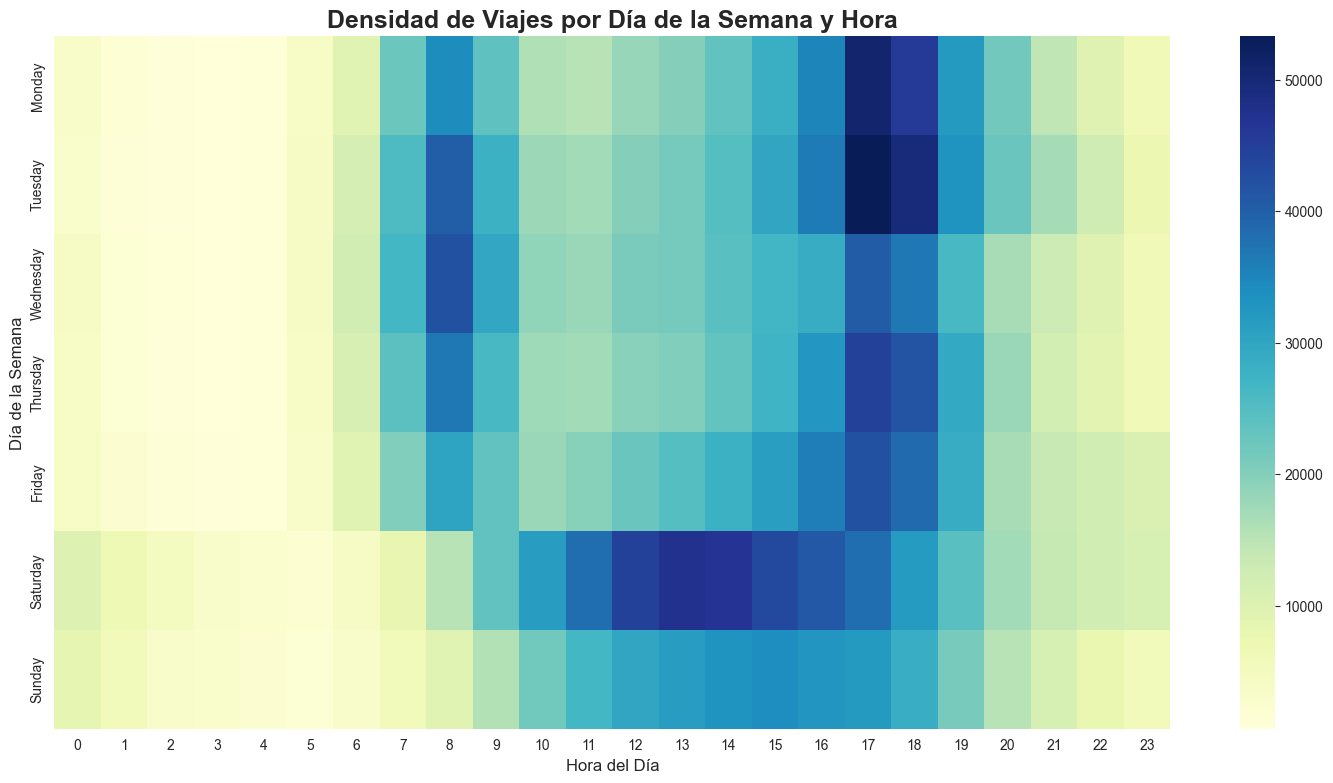

In [ ]:
# Mapa de Calor de densidad de viajes

# Creamos una tabla cruzada (crosstab) para contar los viajes por día y hora
heatmap_data = pd.crosstab(df['day_of_week'], df['start_hour'])

# Reordenamos los días de la semana
dias_ordenados = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_data = heatmap_data.reindex(dias_ordenados)

# Creamos el mapa de calor
plt.figure(figsize=(18, 9))
sns.heatmap(heatmap_data, cmap='YlGnBu', annot=False) # annot=False para no mostrar los números

plt.title('Densidad de viajes por día de la semana y hora', fontsize=18, fontweight='bold')
plt.xlabel('Hora del Día', fontsize=12)
plt.ylabel('Día de la Semana', fontsize=12)
plt.show()

**Interpretación del Gráfico**

Confirma de manera muy clara dos patrones de comportamiento distintos en los usuarios, diferenciando perfectamente los días laborales del fin de semana.

**Patrón 1: Días Laborales (Lunes a Viernes)** - Desplazamiento al trabajo.
Dos picos claros: Se observan dos bandas verticales de color azul oscuro, lo que indica una alta densidad de viajes. Un pico fuerte entre las 7 y las 9 de la mañana y un pico aún más intenso entre las 5 y las 7 de la tarde.

**Patrón 2: Fin de Semana (Sábado y Domingo)** - Usuario de ocio.
Sin picos de hora punta, el patrón de dos picos desaparece por completo. La actividad se concentra en un patrón único y amplio que abarca desde el mediodía hasta bien entrada la tarde (aproximadamente de 12:00 a 18:00)

---

## 3.5 Análisis geoespacial

¿Cuáles son las estaciones más populares?

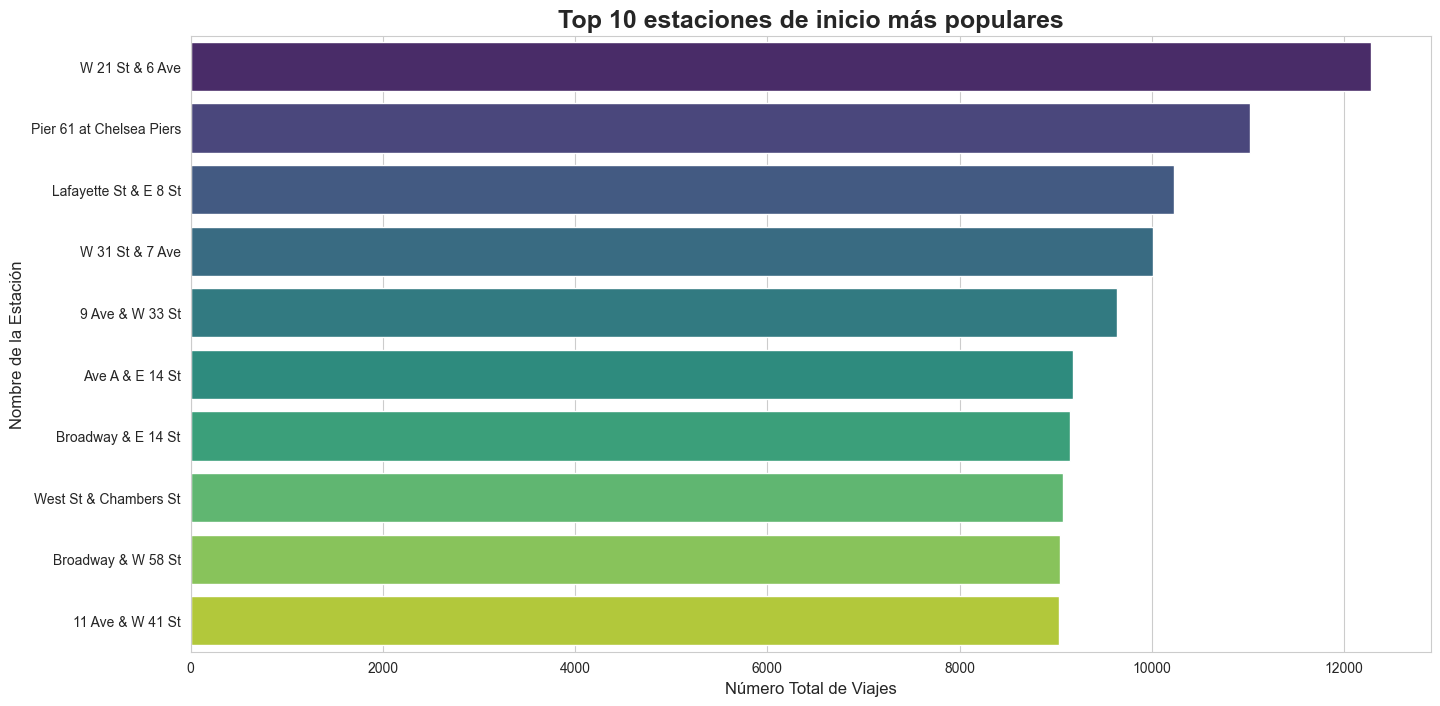

In [6]:
# Gráfico de barra para ver el top 10 de las Estaciones de inicio más populares

# Contamos la frecuencia de cada estación de inicio
top_10_stations = df['station_name_start'].value_counts().head(10)

plt.figure(figsize=(16, 8))
sns.barplot(x=top_10_stations.values, y=top_10_stations.index, palette='viridis', orient='h',hue=top_10_stations.index,legend=False)

plt.title('Top 10 estaciones de inicio más populares', fontsize=18, fontweight='bold')
plt.xlabel('Número Total de Viajes', fontsize=12)
plt.ylabel('Nombre de la Estación', fontsize=12)
plt.show()

**Interpretación del Gráfico**

Existe una concentración significativa de viajes que comienzan en unas pocas ubicaciones clave. La estación más popular, **W 21 St & 6 Ave**, es un punto principal y origina un gran volumen de viajes. Esta visualización es crucial para las operaciones, ya que identifica las estaciones que requieren un reequilibrio más frecuente para garantizar la disponibilidad de bicicletas y suficientes espacios de anclaje.

---

¿Cuáles son las rutas más comunes?

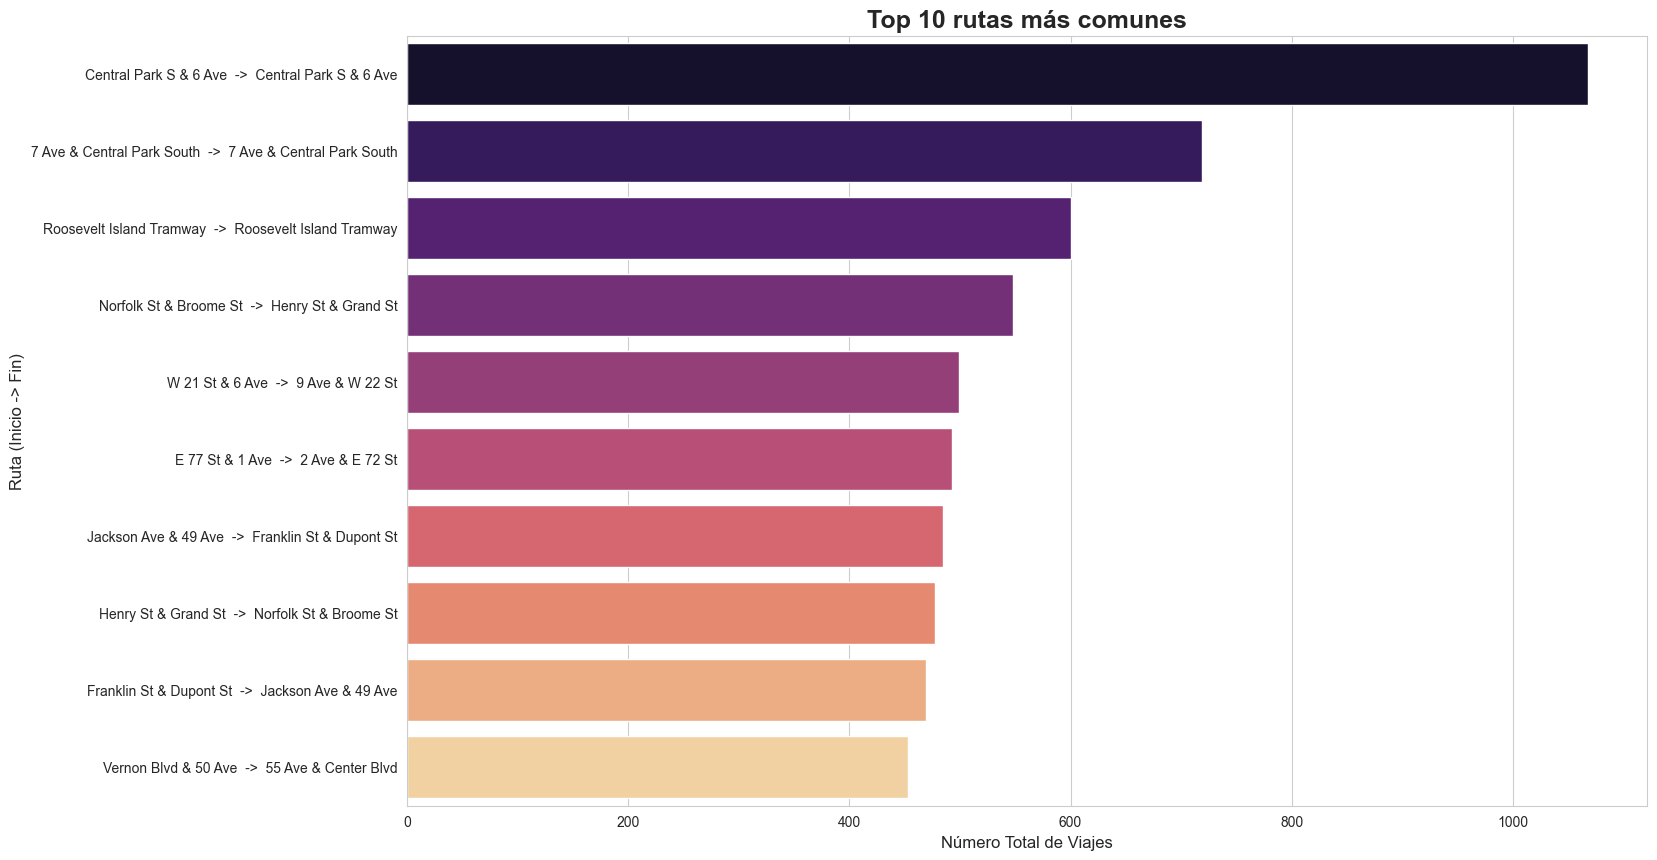

In [36]:
# Gráfico de barra para ver el top 10 rutas más comununes

# Creamos una nueva columna 'route' combinando inicio y fin
df['route'] = df['station_name_start'] + '  ->  ' + df['station_name_end']

# Contamos la frecuencia de cada ruta
top_10_routes = df['route'].value_counts().head(10)

# Creamos el gráfico de barras horizontal
plt.figure(figsize=(16, 10))
sns.barplot(x=top_10_routes.values, y=top_10_routes.index, palette='magma', orient='h',hue= top_10_routes.index, legend=False)

plt.title('Top 10 rutas más comunes', fontsize=18, fontweight='bold')
plt.xlabel('Número Total de Viajes', fontsize=12)
plt.ylabel('Ruta (Inicio -> Fin)', fontsize=12)
plt.show()

**Interpretación del Gráfico**

Este gráfico de barras horizontales muestra claramente las diez rutas más populares, destacando desplazamientos desde zonas residenciales a distritos de oficinas, viajes que empiezan o terminan en estaciones de tren o autobús y trayectos populares a lo largo de parques, zonas de costa o entre puntos de interés turístico.

---

## 3.6 Análisis estadístico de correlaciones

Con esta matriz, buscamos descubrir relaciones lineales entre las variables. Corroborando 

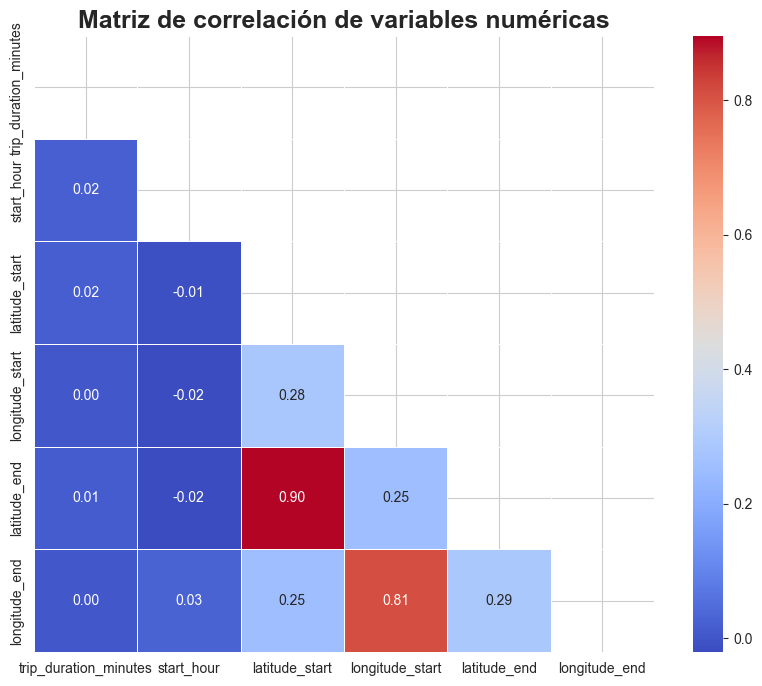

In [37]:
# Matriz de Correlación

# 1. Seleccionamos solo las columnas numéricas que nos interesan
columnas_numericas = [
    'trip_duration_minutes', 
    'start_hour', 
    'latitude_start', 
    'longitude_start', 
    'latitude_end', 
    'longitude_end'
]
df_numerico = df[columnas_numericas]

# 2. Calculamos la matriz de correlación
matriz_correlacion = df_numerico.corr()

# 3. Crear la máscara para ocultar la mitad superior
mask = np.triu(np.ones_like(matriz_correlacion, dtype=bool))

# 4. Creamos el mapa de calor para visualizar la matriz
plt.figure(figsize=(10, 8))
sns.heatmap(
    matriz_correlacion, 
    mask=mask,
    annot=True,        # Muestra los números dentro de cada celda
    cmap='coolwarm',   # Paleta de colores (azul=negativo, rojo=positivo)
    fmt=".2f",         # Formatea los números a 2 decimales
    linewidths=.5 
)

plt.title('Matriz de correlación de variables numéricas', fontsize=18, fontweight='bold')
plt.show()

**Interpretación del Gráfico**

Este gráfico ofrece dos conclusiones principales muy claras.

1. Correlaciones fuertes (rojo intenso): Los viajes son locales.
`latitude_start` y `latitude_end` (0.90): Este valor tan cercano a 1 confirma que los viajes son muy locales en el eje norte-sur. Si un viaje empieza en el norte de la ciudad, es extremadamente probable que termine también en el norte.`longitude_start` y `longitude_end` (0.81): Lo mismo ocurre en el eje este-oeste. Los viajes no suelen cruzar la ciudad de un extremo a otro.

    Conclusión principal: La gente usa las bicicletas para moverse dentro zonas cercanas, no para hacer trayectos largos que crucen toda la ciudad.

2. Correlaciones débiles (casi blancas): La duración y la hora son independientes.
`trip_duration_minutes`: toda la fila y columna tienen valores muy cercanos a cero (0.02, 0.00, 0.01). Esto significa que la duración de un viaje no depende de la hora a la que empiece ni de su ubicación.`start_hour`: de manera similar, la hora de inicio no está relacionada con la ubicación. Se inician viajes por toda la ciudad a lo largo del día.

    Conclusión principal: La hora del día no determina la duración del viaje ni su ubicación. Son variables independientes.

En Resumen:
El análisis de correlación ha demostrado cuantitativamente que el servicio de bicicletas se usa para viajes cortos y locales y que no hay una relación lineal simple entre la hora, la duración y la ubicación de los viajes.